Random Forest Model

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
import seaborn as sns
import xgboost as xgb

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix, classification_report, balanced_accuracy_score
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier

In [4]:
# use cvd risk level not cvd risk score
# blood pressure categories found from https://www.heart.org/en/health-topics/high-blood-pressure/understanding-blood-pressure-readings
# remove systolic, diastolic, and blood pressure, just keep blood pressure category (determined by systolic over diastolic values)

df = pd.read_csv('cvd_dataset.csv').dropna(subset=['CVD Risk Score'])
df_male = pd.read_csv('male_cvd_dataset.csv').dropna()
df_female = pd.read_csv('female_cvd_dataset.csv').dropna()

def dataset_rev(df):
    df_edited = df.drop(columns=['Blood Pressure (mmHg)','Systolic BP','Diastolic BP'])

    # ordinal encoding categories
    sex_categories = ['F','M'] 
    physical_activity_categories = ['Low','Moderate','High']
    blood_pressure_categories = ['Normal','Elevated','Hypertension Stage 1','Hypertension Stage 2']
    # smoking, diabetes, family history all Y/N (0,1)
    yn_categories = ['Y','N']
    # cvd risk levels (0,1,2)
    risk_categories = ['LOW','INTERMEDIARY','HIGH']

    encoder = OrdinalEncoder(categories=[sex_categories, physical_activity_categories, blood_pressure_categories, yn_categories, yn_categories, yn_categories,risk_categories])
    df_edited[['Sex','Physical Activity Level','Blood Pressure Category','Smoking Status','Diabetes Status','Family History of CVD','CVD Risk Level']] = encoder.fit_transform(df_edited[['Sex','Physical Activity Level','Blood Pressure Category','Smoking Status','Diabetes Status','Family History of CVD','CVD Risk Level']])

    X = df_edited.drop(columns=['CVD Risk Level','CVD Risk Score'])
    y = df_edited['CVD Risk Level']

    return X, y,encoder

fem_X, fem_y,encoder = dataset_rev(df_female)
male_X, male_y,encoder = dataset_rev(df_male)
X,y,encoder = dataset_rev(df)

In [6]:
def graph_vis(all_y_true,all_y_pred):
    cm = confusion_matrix(all_y_true, all_y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues') # 'annot=True' displays the numbers, 'fmt="d"' ensures integer formatting
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()
    df_preds = pd.DataFrame({"True": [int(x) for x in all_y_true],
                            "Predicted": all_y_pred})

    sns.countplot(x="True", data=df_preds, label="True", color="skyblue")
    sns.countplot(x="Predicted", data=df_preds, label="Predicted", color="salmon", alpha=0.5)
    plt.legend()
    plt.title("Distribution of True vs Predicted Labels")
    plt.show()

1 :  0.6835443037974683
2 :  0.5063291139240507
3 :  0.5949367088607594
4 :  0.620253164556962
5 :  0.6923076923076923
              precision    recall  f1-score   support

         LOW       0.00      0.00      0.00        51
INTERMEDIARY       0.60      0.63      0.62       152
        HIGH       0.66      0.77      0.71       191

    accuracy                           0.62       394
   macro avg       0.42      0.47      0.44       394
weighted avg       0.55      0.62      0.58       394



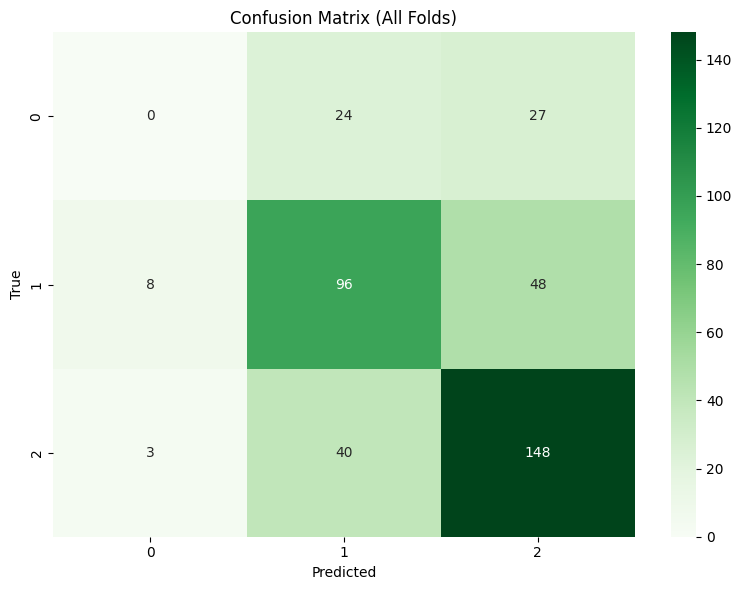

Cross-Validation Results (Accuracy):
  Fold 1: 68.35%
  Fold 2: 50.63%
  Fold 3: 59.49%
  Fold 4: 62.03%
  Fold 5: 69.23%


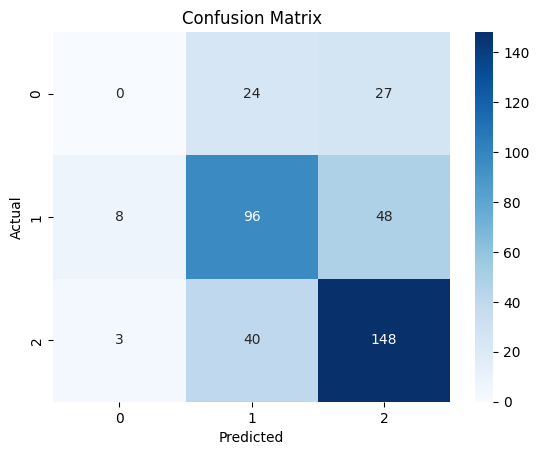

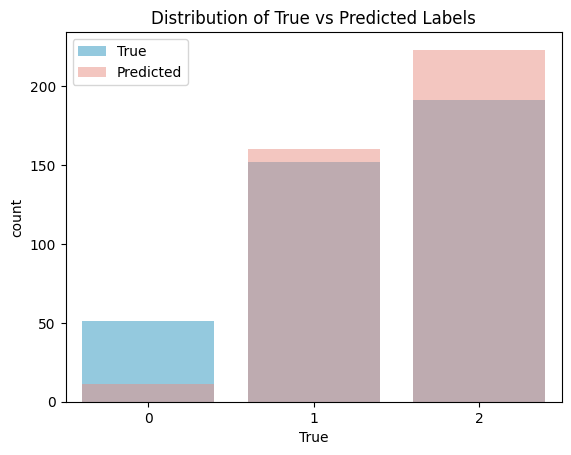

In [7]:
kf = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
metrics = []
all_y_true = []
all_y_pred = []

RandomForestClassifier(n_estimators=500,
    class_weight="balanced",
    random_state=42,
    max_depth=-1,
    max_features="sqrt"
)

fold_num = 1
for train_index, test_index in kf.split(fem_X,fem_y): # splits dataset into stratified train-test indices
    X_train, X_test = fem_X.iloc[train_index], fem_X.iloc[test_index] # features
    y_train, y_test = fem_y.iloc[train_index], fem_y.iloc[test_index] # labels
    
    random_forest = RandomForestClassifier(random_state=42)
    random_forest.fit(X_train, y_train)

    y_pred = random_forest.predict(X_test).astype(int)

    accuracy = accuracy_score(y_test, y_pred)
    print(fold_num, ': ',accuracy)
    fold_num += 1
    metrics.append(accuracy)
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)

print(classification_report(all_y_true, all_y_pred, target_names=encoder.categories_[6]))
cm = confusion_matrix(all_y_true, all_y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (All Folds)')
plt.tight_layout()
plt.show()

print("Cross-Validation Results (Accuracy):")
for i, result in enumerate(metrics, 1):
    print(f"  Fold {i}: {result * 100:.2f}%")

graph_vis(all_y_true,all_y_pred)

In [26]:
print(y.value_counts(normalize=True))

CVD Risk Level
2.0    0.482940
1.0    0.375328
0.0    0.141732
Name: proportion, dtype: float64
